In [43]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.pyplot import cm 
import numpy as np 
import pandas as pd
import math

from astropy.table import Table

In [44]:
script = pd.read_csv('slope-data.csv')

slopes = script['slope_2']
d_slopes = script['d_slope_2']
fritz_slopes = script['slope_fritz_2']
slope_diff = np.abs(fritz_slopes - slopes)

F115W_F212N_F115W = []
F115W_F212N_F212N = []
F212N_F323N_F212N = []
F212N_F323N_F323N = []
F212N_F405N_F212N = []
F212N_F405N_F405N = []

idx = 0
while idx < len(slopes): 
    F115W_F212N_F115W.append([slopes[idx], fritz_slopes[idx], d_slopes[idx]])
    F115W_F212N_F212N.append([slopes[idx+1], fritz_slopes[idx+1], d_slopes[idx+1]])
    F212N_F323N_F212N.append([slopes[idx+2], fritz_slopes[idx+2], d_slopes[idx+2]])
    F212N_F323N_F323N.append([slopes[idx+3], fritz_slopes[idx+3], d_slopes[idx+3]])
    F212N_F405N_F212N.append([slopes[idx+4], fritz_slopes[idx+4], d_slopes[idx+4]])
    F212N_F405N_F405N.append([slopes[idx+5], fritz_slopes[idx+5], d_slopes[idx+5]])
    idx += 6

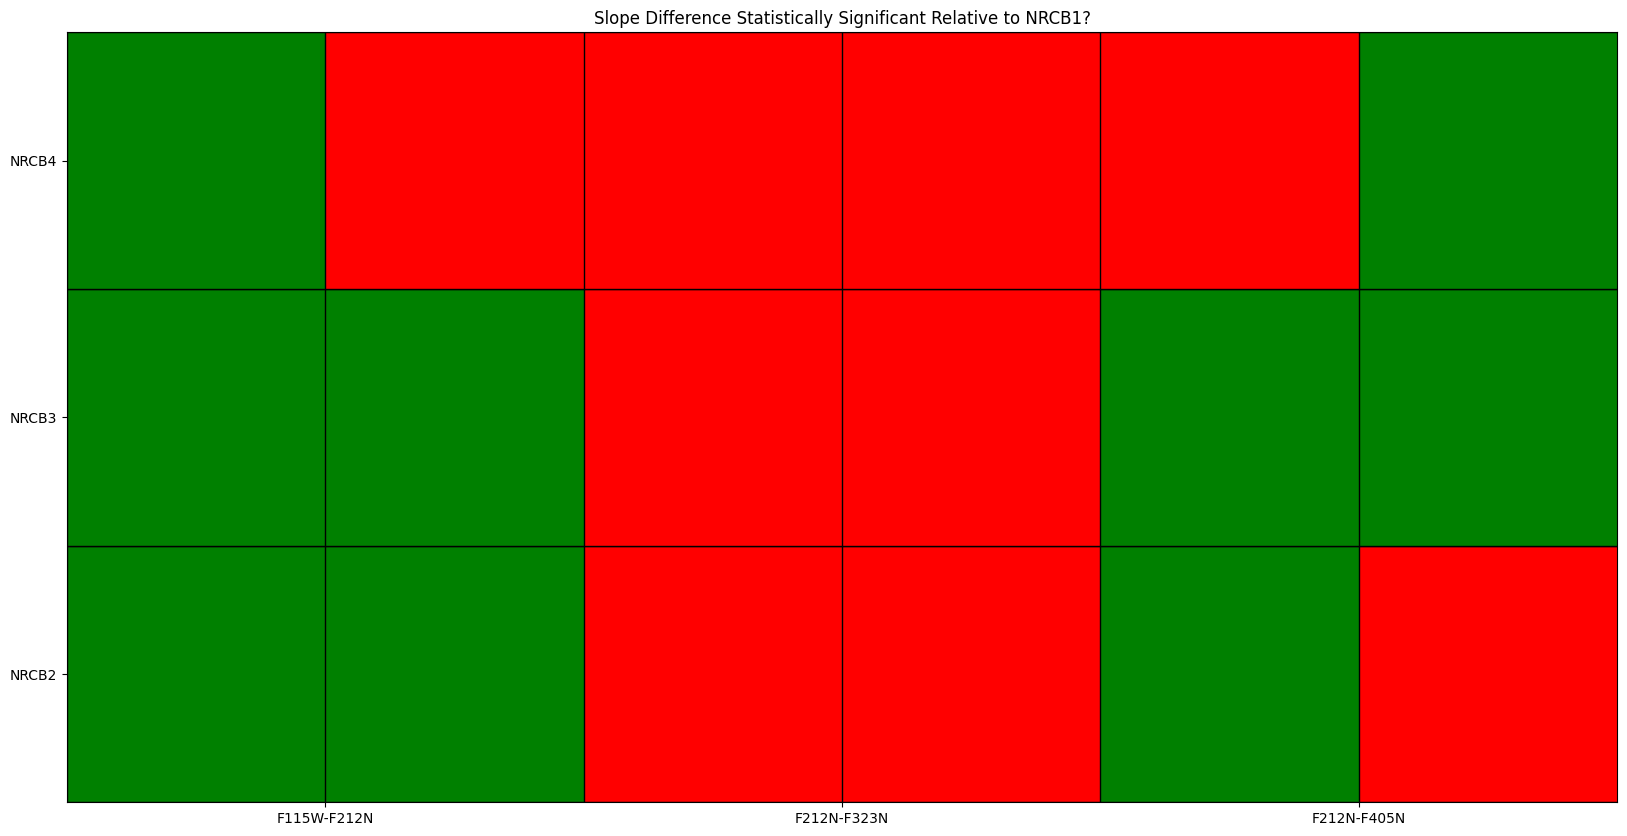

In [45]:
stat_significant_list = []

fig, axis = plt.subplots(figsize = (20, 10))
axis.get_xaxis().set_ticks([])
axis.get_yaxis().set_ticks([])
plt.xlim(0, 3)
plt.ylim(0, 3)
plt.title('Slope Difference Statistically Significant Relative to NRCB1?')
start_x = 0
start_y = 0

count = 0
list_names = ['F115W_F212N_F115W', 'F115W_F212N_F212N', 'F212N_F323N_F212N', 'F212N_F323N_F323N', 'F212N_F405N_F212N', 'F212N_F405N_F405N']
for i in [F115W_F212N_F115W, F115W_F212N_F212N, F212N_F323N_F212N, F212N_F323N_F323N, F212N_F405N_F212N, F212N_F405N_F405N]: 
    NRCB1_error = i[0][2]
    NRCB1_slope = i[0][0]
    NRCB2_error = i[1][2]
    NRCB2_slope = i[1][0]
    NRCB3_error = i[2][2]
    NRCB3_slope = i[2][0]
    NRCB4_error = i[3][2]
    NRCB4_slope = i[3][0]

    stat_significant_list = [
                                abs(NRCB1_slope - NRCB2_slope) <= 3* math.sqrt(NRCB1_error**2 + NRCB2_error**2), 
                                abs(NRCB1_slope - NRCB3_slope) <= 3* math.sqrt(NRCB1_error**2 + NRCB3_error**2), 
                                abs(NRCB1_slope - NRCB4_slope) <= 3* math.sqrt(NRCB1_error**2 + NRCB4_error**2)
                            ]

    if stat_significant_list[0]: 
        rect = Rectangle((start_x, start_y), 1, 1, facecolor = 'green', linestyle = '-', edgecolor = 'black', linewidth = 1)
        axis.add_patch(rect)
    else: 
        rect = Rectangle((start_x, start_y), 1, 1, facecolor = 'red', linestyle = '-', edgecolor = 'black', linewidth = 1)
        axis.add_patch(rect)
    start_y += 1
    if stat_significant_list[1]: 
        rect = Rectangle((start_x, start_y), 1, 1, facecolor = 'green', linestyle = '-', edgecolor = 'black', linewidth = 1)
        axis.add_patch(rect)
    else: 
        rect = Rectangle((start_x, start_y), 1, 1, facecolor = 'red', linestyle = '-', edgecolor = 'black', linewidth = 1)
        axis.add_patch(rect)
    start_y += 1
    if stat_significant_list[2]: 
        rect = Rectangle((start_x, start_y), 1, 1, facecolor = 'green', linestyle = '-', edgecolor = 'black', linewidth = 1)
        axis.add_patch(rect)
    else: 
        rect = Rectangle((start_x, start_y), 1, 1, facecolor = 'red', linestyle = '-', edgecolor = 'black', linewidth = 1)
        axis.add_patch(rect)
    start_y = 0 
    start_x +=0.5

    count+=1

    tick_positions = [0.5, 1.5, 2.5]
    tick_labels = ['NRCB2', 'NRCB3', 'NRCB4']
    axis.set_yticks(tick_positions)
    axis.set_yticklabels(tick_labels)

    tick_positions = [0.5, 1.5, 2.5]
    tick_labels = ['F115W-F212N', 'F212N-F323N', 'F212N-F405N']
    axis.set_xticks(tick_positions)
    axis.set_xticklabels(tick_labels)

In [46]:
NRCB2_extinction

[3.4453081077191587, 1, -1.3946177385461034, 0.3180527374829596]

Text(0, 0.5, '$A_\\lambda / A_{K_s}$')

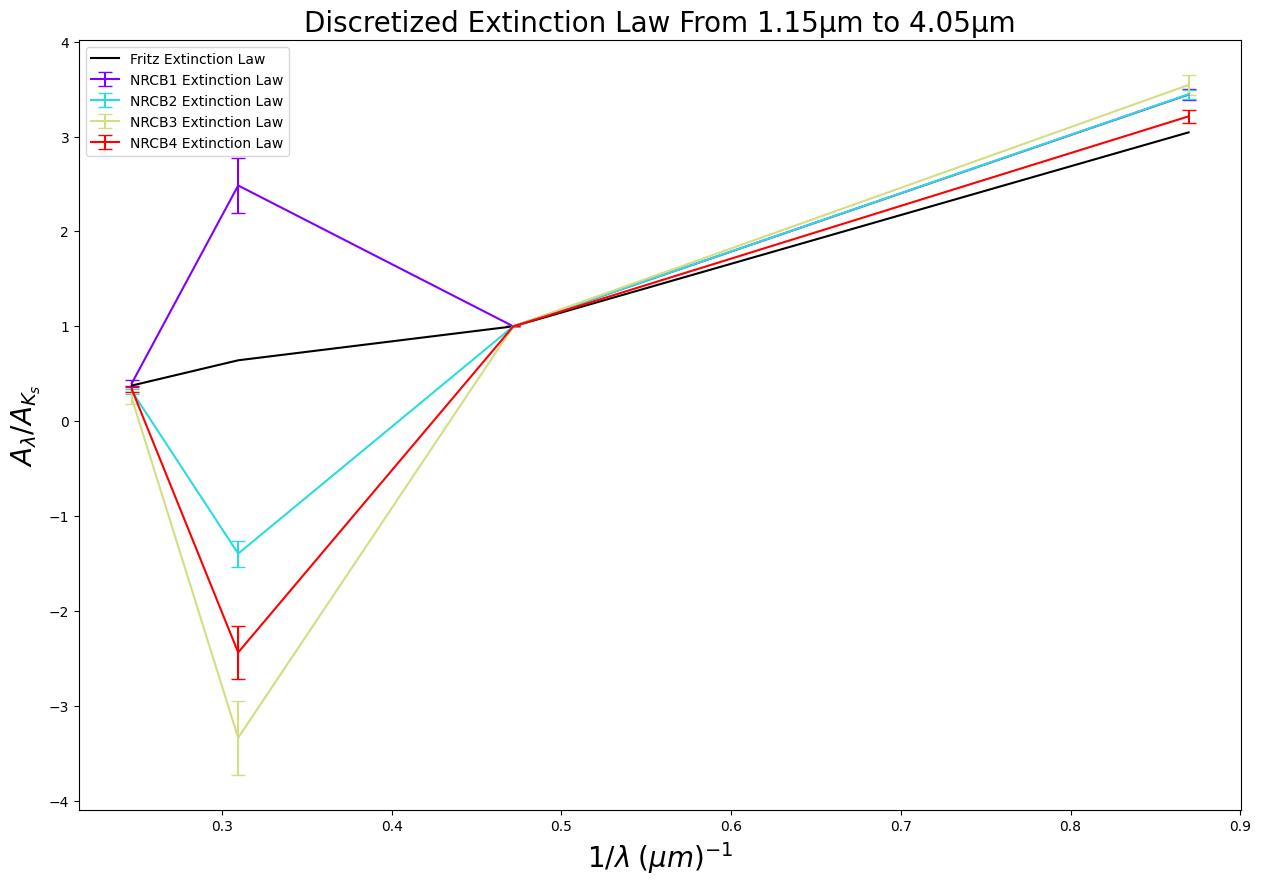

In [47]:
A_115W_Ks = []
A_323N_Ks = []
A_405N_Ks = []

A_115W_Ks_e = []
A_323N_Ks_e = []
A_405N_Ks_e = []

for i in range(len(F115W_F212N_F115W)): 
    A_115W_Ks.append([F115W_F212N_F115W[i][0] / F115W_F212N_F212N[i][0], F115W_F212N_F115W[i][1] / F115W_F212N_F212N[i][1]])
    A_323N_Ks.append([F212N_F323N_F323N[i][0] / F212N_F323N_F212N[i][0], F212N_F323N_F323N[i][1] / F212N_F323N_F212N[i][1]])
    A_405N_Ks.append([F212N_F405N_F405N[i][0] / F212N_F405N_F212N[i][0], F212N_F405N_F405N[i][1] / F212N_F405N_F212N[i][1]])

for i in range(len(A_115W_Ks)): 
    A_115W_Ks_e.append(A_115W_Ks[i][0] * math.sqrt((F115W_F212N_F115W[i][2] / F115W_F212N_F115W[i][0])**2 + (F115W_F212N_F212N[i][2] / F115W_F212N_F212N[i][0])**2 ))
    A_323N_Ks_e.append(abs(A_323N_Ks[i][0]) * math.sqrt((F212N_F323N_F323N[i][2] / F212N_F323N_F323N[i][0])**2 + (F212N_F323N_F212N[i][2] / F212N_F323N_F212N[i][0])**2 ))
    A_405N_Ks_e.append(A_405N_Ks[i][0] * math.sqrt((F212N_F405N_F405N[i][2] / F212N_F405N_F405N[i][0])**2 + (F212N_F405N_F212N[i][2] / F212N_F405N_F212N[i][0])**2 ))

NRCB1_extinction = [A_115W_Ks[0][0], 1, A_323N_Ks[0][0], A_405N_Ks[0][0]]
NRCB2_extinction = [A_115W_Ks[1][0], 1, A_323N_Ks[1][0], A_405N_Ks[1][0]]
NRCB3_extinction = [A_115W_Ks[2][0], 1, A_323N_Ks[2][0], A_405N_Ks[2][0]]
NRCB4_extinction = [A_115W_Ks[3][0], 1, A_323N_Ks[3][0], A_405N_Ks[3][0]]

NRCB1_extinction_e = [A_115W_Ks_e[0], 0, A_323N_Ks_e[0], A_405N_Ks_e[0]]
NRCB2_extinction_e = [A_115W_Ks_e[1], 0, A_323N_Ks_e[1], A_405N_Ks_e[1]]
NRCB3_extinction_e = [A_115W_Ks_e[2], 0, A_323N_Ks_e[2], A_405N_Ks_e[2]]
NRCB4_extinction_e = [A_115W_Ks_e[3], 0, A_323N_Ks_e[3], A_405N_Ks_e[3]]



fritz_extinction = [A_115W_Ks[0][1], 1, A_323N_Ks[0][1], A_405N_Ks[0][1]]

fig, axis = plt.subplots(1, 1, figsize = (15, 10))

x_values = [1/1.15, 1/2.12, 1/3.23, 1/4.05]

colors = cm.rainbow(np.linspace(0, 1, 4))

plt.errorbar(x_values, NRCB1_extinction, yerr = NRCB1_extinction_e, c = colors[0], capsize=5, label = 'NRCB1 Extinction Law')
plt.errorbar(x_values, NRCB2_extinction, yerr = NRCB2_extinction_e, c = colors[1], capsize=5, label = 'NRCB2 Extinction Law')
plt.errorbar(x_values, NRCB3_extinction, yerr = NRCB3_extinction_e, c = colors[2], capsize=5, label = 'NRCB3 Extinction Law')
plt.errorbar(x_values, NRCB4_extinction, yerr = NRCB4_extinction_e,  c = colors[3], capsize=5, label = 'NRCB4 Extinction Law')

plt.plot(x_values, fritz_extinction, c = 'k', label = 'Fritz Extinction Law')



plt.title('Discretized Extinction Law From 1.15µm to 4.05µm', fontsize = 20)

plt.legend()
plt.xlabel(r'$1/\lambda \; (\mu m)^{-1}$', fontsize = 20)
plt.ylabel(r'$A_\lambda / A_{K_s}$', fontsize = 20)



In [25]:
NRCB2_extinction_e

[0.05015176794568893, 0, -0.13682758851454085, 0.02627636193544063]

In [17]:
NRCB1_extinction, NRCB2_extinction, NRCB3_extinction, NRCB4_extinction

([3.439522571987667, 1, 2.9912918873584764, 0.39970368388097394],
 [3.4453081107434995, 1, 2.008444097222826, 0.34406063541324355],
 [3.543608318533413, 1, 3.281891901063658, 0.24318227565430625],
 [3.212185601785418, 1, 2.4922811647452736, 0.3372744915138025])

In [18]:
NRCB1_extinction_e, NRCB2_extinction_e, NRCB3_extinction_e, NRCB4_extinction_e

([0.05916099898334173, 0, 0.4102064480206282, 0.03052487427149192],
 [0.05015176820601568, 0, 0.3927035811128013, 0.0313389164318753],
 [0.10653642471104069, 0, 0.4308174103861761, 0.06133824466426115],
 [0.06454416971275805, 0, 0.46772080156679285, 0.0288291209480046])

Text(0, 0.5, '$A_\\lambda / A_{K_s}$')

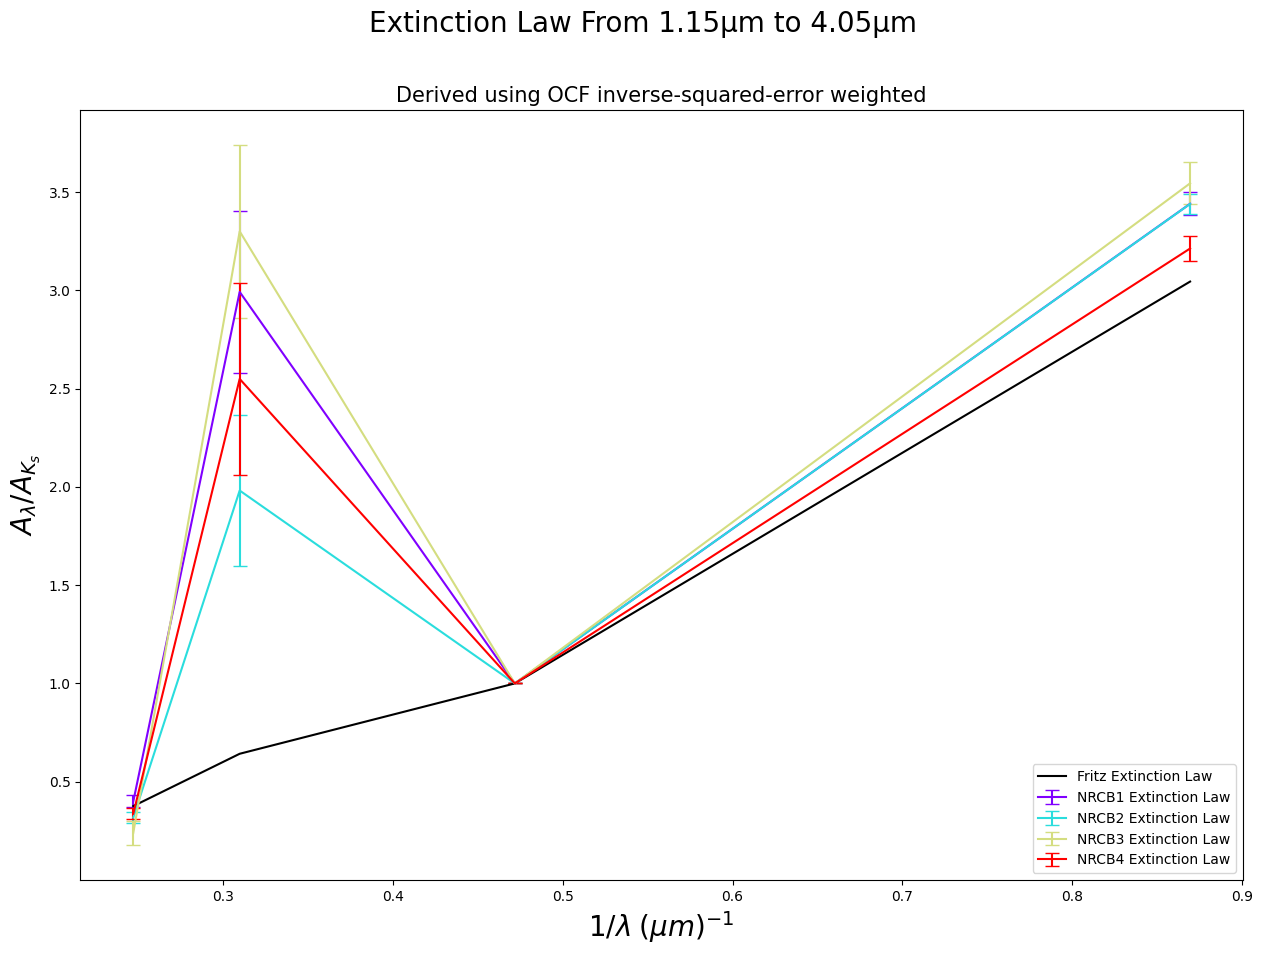

In [5]:
A_115W_Ks = []
A_323N_Ks = []
A_405N_Ks = []

A_115W_Ks_e = []
A_323N_Ks_e = []
A_405N_Ks_e = []

for i in range(len(F115W_F212N_F115W)): 
    A_115W_Ks.append([F115W_F212N_F115W[i][0] / F115W_F212N_F212N[i][0], F115W_F212N_F115W[i][1] / F115W_F212N_F212N[i][1]])
    A_323N_Ks.append([F212N_F323N_F323N[i][0] / F212N_F323N_F212N[i][0], F212N_F323N_F323N[i][1] / F212N_F323N_F212N[i][1]])
    A_405N_Ks.append([F212N_F405N_F405N[i][0] / F212N_F405N_F212N[i][0], F212N_F405N_F405N[i][1] / F212N_F405N_F212N[i][1]])

for i in range(len(A_115W_Ks)): 
    A_115W_Ks_e.append(A_115W_Ks[i][0] * math.sqrt((F115W_F212N_F115W[i][2] / F115W_F212N_F115W[i][0])**2 + (F115W_F212N_F212N[i][2] / F115W_F212N_F212N[i][0])**2 ))
    A_323N_Ks_e.append(A_323N_Ks[i][0] * math.sqrt((F212N_F323N_F323N[i][2] / F212N_F323N_F323N[i][0])**2 + (F212N_F323N_F212N[i][2] / F212N_F323N_F212N[i][0])**2 ))
    A_405N_Ks_e.append(A_405N_Ks[i][0] * math.sqrt((F212N_F405N_F405N[i][2] / F212N_F405N_F405N[i][0])**2 + (F212N_F405N_F212N[i][2] / F212N_F405N_F212N[i][0])**2 ))

NRCB1_extinction = [A_115W_Ks[0][0], 1, A_323N_Ks[0][0], A_405N_Ks[0][0]]
NRCB2_extinction = [A_115W_Ks[1][0], 1, A_323N_Ks[1][0], A_405N_Ks[1][0]]
NRCB3_extinction = [A_115W_Ks[2][0], 1, A_323N_Ks[2][0], A_405N_Ks[2][0]]
NRCB4_extinction = [A_115W_Ks[3][0], 1, A_323N_Ks[3][0], A_405N_Ks[3][0]]

NRCB1_extinction_e = [A_115W_Ks_e[0], 0, A_323N_Ks_e[0], A_405N_Ks_e[0]]
NRCB2_extinction_e = [A_115W_Ks_e[1], 0, A_323N_Ks_e[1], A_405N_Ks_e[1]]
NRCB3_extinction_e = [A_115W_Ks_e[2], 0, A_323N_Ks_e[2], A_405N_Ks_e[2]]
NRCB4_extinction_e = [A_115W_Ks_e[3], 0, A_323N_Ks_e[3], A_405N_Ks_e[3]]



fritz_extinction = [A_115W_Ks[0][1], 1, A_323N_Ks[0][1], A_405N_Ks[0][1]]

fig, axis = plt.subplots(1, 1, figsize = (15, 10))

x_values = [1/1.15, 1/2.12, 1/3.23, 1/4.05]

colors = cm.rainbow(np.linspace(0, 1, 4))

plt.errorbar(x_values, NRCB1_extinction, yerr = NRCB1_extinction_e, c = colors[0], capsize=5, label = 'NRCB1 Extinction Law')
plt.errorbar(x_values, NRCB2_extinction, yerr = NRCB2_extinction_e, c = colors[1], capsize=5, label = 'NRCB2 Extinction Law')
plt.errorbar(x_values, NRCB3_extinction, yerr = NRCB3_extinction_e, c = colors[2], capsize=5, label = 'NRCB3 Extinction Law')
plt.errorbar(x_values, NRCB4_extinction, yerr = NRCB4_extinction_e,  c = colors[3], capsize=5, label = 'NRCB4 Extinction Law')

plt.plot(x_values, fritz_extinction, c = 'k', label = 'Fritz Extinction Law')



plt.suptitle('Extinction Law From 1.15µm to 4.05µm', fontsize = 20)
plt.title('Derived using OCF inverse-squared-error weighted', fontsize = 15)

plt.legend()
plt.xlabel(r'$1/\lambda \; (\mu m)^{-1}$', fontsize = 20)
plt.ylabel(r'$A_\lambda / A_{K_s}$', fontsize = 20)


Text(0, 0.5, '$A_\\lambda / A_{K_s}$')

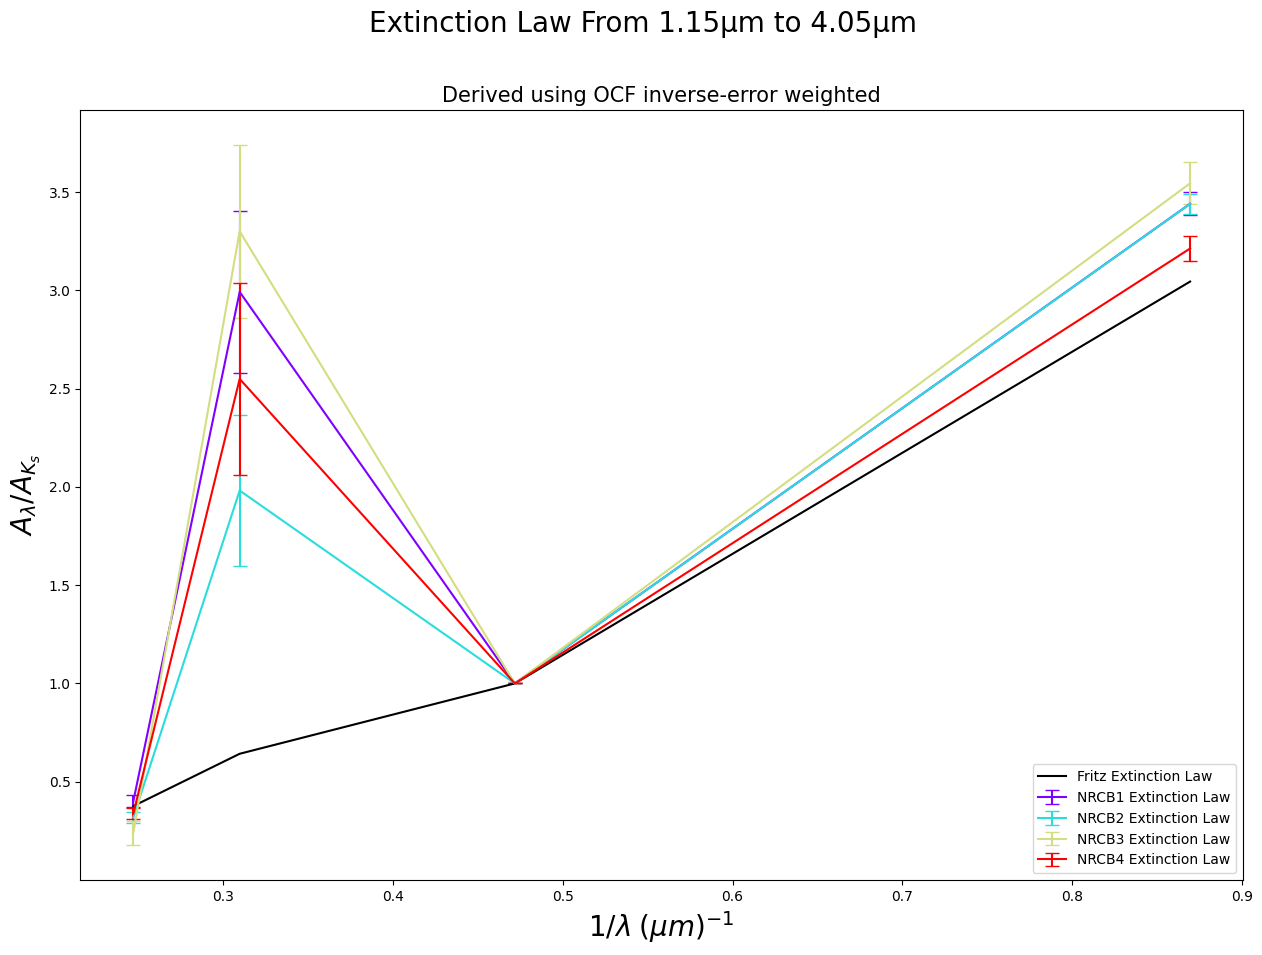

In [6]:
A_115W_Ks = []
A_323N_Ks = []
A_405N_Ks = []

A_115W_Ks_e = []
A_323N_Ks_e = []
A_405N_Ks_e = []

for i in range(len(F115W_F212N_F115W)): 
    A_115W_Ks.append([F115W_F212N_F115W[i][0] / F115W_F212N_F212N[i][0], F115W_F212N_F115W[i][1] / F115W_F212N_F212N[i][1]])
    A_323N_Ks.append([F212N_F323N_F323N[i][0] / F212N_F323N_F212N[i][0], F212N_F323N_F323N[i][1] / F212N_F323N_F212N[i][1]])
    A_405N_Ks.append([F212N_F405N_F405N[i][0] / F212N_F405N_F212N[i][0], F212N_F405N_F405N[i][1] / F212N_F405N_F212N[i][1]])

for i in range(len(A_115W_Ks)): 
    A_115W_Ks_e.append(A_115W_Ks[i][0] * math.sqrt((F115W_F212N_F115W[i][2] / F115W_F212N_F115W[i][0])**2 + (F115W_F212N_F212N[i][2] / F115W_F212N_F212N[i][0])**2 ))
    A_323N_Ks_e.append(A_323N_Ks[i][0] * math.sqrt((F212N_F323N_F323N[i][2] / F212N_F323N_F323N[i][0])**2 + (F212N_F323N_F212N[i][2] / F212N_F323N_F212N[i][0])**2 ))
    A_405N_Ks_e.append(A_405N_Ks[i][0] * math.sqrt((F212N_F405N_F405N[i][2] / F212N_F405N_F405N[i][0])**2 + (F212N_F405N_F212N[i][2] / F212N_F405N_F212N[i][0])**2 ))

NRCB1_extinction = [A_115W_Ks[0][0], 1, A_323N_Ks[0][0], A_405N_Ks[0][0]]
NRCB2_extinction = [A_115W_Ks[1][0], 1, A_323N_Ks[1][0], A_405N_Ks[1][0]]
NRCB3_extinction = [A_115W_Ks[2][0], 1, A_323N_Ks[2][0], A_405N_Ks[2][0]]
NRCB4_extinction = [A_115W_Ks[3][0], 1, A_323N_Ks[3][0], A_405N_Ks[3][0]]

NRCB1_extinction_e = [A_115W_Ks_e[0], 0, A_323N_Ks_e[0], A_405N_Ks_e[0]]
NRCB2_extinction_e = [A_115W_Ks_e[1], 0, A_323N_Ks_e[1], A_405N_Ks_e[1]]
NRCB3_extinction_e = [A_115W_Ks_e[2], 0, A_323N_Ks_e[2], A_405N_Ks_e[2]]
NRCB4_extinction_e = [A_115W_Ks_e[3], 0, A_323N_Ks_e[3], A_405N_Ks_e[3]]



fritz_extinction = [A_115W_Ks[0][1], 1, A_323N_Ks[0][1], A_405N_Ks[0][1]]

fig, axis = plt.subplots(1, 1, figsize = (15, 10))

x_values = [1/1.15, 1/2.12, 1/3.23, 1/4.05]

colors = cm.rainbow(np.linspace(0, 1, 4))

plt.errorbar(x_values, NRCB1_extinction, yerr = NRCB1_extinction_e, c = colors[0], capsize=5, label = 'NRCB1 Extinction Law')
plt.errorbar(x_values, NRCB2_extinction, yerr = NRCB2_extinction_e, c = colors[1], capsize=5, label = 'NRCB2 Extinction Law')
plt.errorbar(x_values, NRCB3_extinction, yerr = NRCB3_extinction_e, c = colors[2], capsize=5, label = 'NRCB3 Extinction Law')
plt.errorbar(x_values, NRCB4_extinction, yerr = NRCB4_extinction_e,  c = colors[3], capsize=5, label = 'NRCB4 Extinction Law')

plt.plot(x_values, fritz_extinction, c = 'k', label = 'Fritz Extinction Law')



plt.suptitle('Extinction Law From 1.15µm to 4.05µm', fontsize = 20)
plt.title('Derived using OCF inverse-error weighted', fontsize = 15)

plt.legend()
plt.xlabel(r'$1/\lambda \; (\mu m)^{-1}$', fontsize = 20)
plt.ylabel(r'$A_\lambda / A_{K_s}$', fontsize = 20)
